# Sinhala Text → Sinhala Sign Language Translation
## Kaggle Notebook — Full Pipeline (Improved)
---
**Architecture:** XLM-RoBERTa Encoder + Transformer Decoder  
**Input:** Sinhala text | **Output:** SSL gloss words + sign IDs  
**Dataset format:** `sentence@id:gloss|id:gloss|...`

### Improvements over v1
1. Separate source (XLM-R) and target (custom sign vocab) tokenizers
2. Bottom encoder layers frozen — prevents catastrophic forgetting
3. Beam search with KV-cache — much faster inference
4. Proper length penalty (Wu et al. 2016)
5. Fixed fuzzy vocab lookup with prefix index
6. Scheduler + scaler saved in checkpoints (safe resume)
7. Seeded DataLoader workers for reproducibility
8. CFG dataclass with validation
9. Duplicate vocab conflict warnings
10. Full evaluation: BLEU, chrF, TER, ROUGE, METEOR, WER, BERTScore


In [1]:
# ───────────────────────────────────────────────────────
# CELL 1 — Install Dependencies
# ───────────────────────────────────────────────────────
!pip install transformers sentencepiece sacrebleu rouge-score jiwer bert-score -q

import torch
print("PyTorch   :", torch.__version__)
print("CUDA      :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU       :", torch.cuda.get_device_name(0))
    print("VRAM      :", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.5 MB/s eta 0:00:00:00:01
PyTorch   : 2.10.0+cu128
CUDA      : True
GPU       : Tesla T4
VRAM      : 15.6 GB


In [2]:
# ───────────────────────────────────────────────────────
# CELL 2 — Configuration  (dataclass with validation)
# ───────────────────────────────────────────────────────
import os
from dataclasses import dataclass, field

@dataclass
class CFG:
    # ── Paths ──────────────────────────────────────────────────────
    CORPUS_FILE   : str   = "/kaggle/input/datasets/nadeenudantha/full-corpus3-converted/full-corpus3-converted.txt"
    OUTPUT_DIR    : str   = "/kaggle/working"
    MODEL_DIR     : str   = "/kaggle/working/models"
    LOG_FILE      : str   = "/kaggle/working/training_log.csv"

    # ── Model ──────────────────────────────────────────────────────
    ENCODER_MODEL : str   = "xlm-roberta-base"
    D_MODEL       : int   = 768
    N_HEADS       : int   = 8
    N_DEC_LAYERS  : int   = 4
    DIM_FFN       : int   = 2048
    DROPOUT       : float = 0.1
    MAX_SRC_LEN   : int   = 64
    MAX_TGT_LEN   : int   = 32

    # ── Encoder freezing ──────────────────────────────────────────
    # XLM-RoBERTa-base has 12 transformer layers (0-11).
    # Freeze bottom FREEZE_ENCODER_LAYERS to prevent catastrophic
    # forgetting on the small ~8k SSL dataset.
    FREEZE_ENCODER_LAYERS : int = 8   # keep layers 8-11 trainable

    # ── Training ──────────────────────────────────────────────────
    EPOCHS        : int   = 50
    BATCH_SIZE    : int   = 16
    ENCODER_LR    : float = 2e-5      # small — preserve BERT knowledge
    DECODER_LR    : float = 5e-4      # larger — decoder learns from scratch
    WEIGHT_DECAY  : float = 1e-2
    WARMUP_RATIO  : float = 0.1
    GRAD_CLIP     : float = 1.0
    ACCUM_STEPS   : int   = 2         # effective batch = BATCH_SIZE * ACCUM_STEPS
    LABEL_SMOOTH  : float = 0.1
    PATIENCE      : int   = 8         # early stopping

    # ── Beam search ───────────────────────────────────────────────
    BEAM_SIZE           : int   = 4
    BEAM_LENGTH_PENALTY : float = 0.6  # Wu et al. 2016 Google NMT

    # ── Data split ────────────────────────────────────────────────
    TEST_RATIO    : float = 0.15
    VAL_RATIO     : float = 0.10
    SEED          : int   = 42

    # ── Memory ────────────────────────────────────────────────────
    USE_AMP       : bool  = True
    GRAD_CKPT     : bool  = True
    NUM_WORKERS   : int   = 2
    PIN_MEMORY    : bool  = True

    def __post_init__(self):
        assert self.BATCH_SIZE > 0,      "BATCH_SIZE must be > 0"
        assert 0 < self.ENCODER_LR < 1,  "ENCODER_LR looks wrong"
        assert 0 < self.DECODER_LR < 1,  "DECODER_LR looks wrong"
        assert self.N_HEADS > 0,         "N_HEADS must be > 0"
        assert self.D_MODEL % self.N_HEADS == 0, (
            f"D_MODEL ({self.D_MODEL}) must be divisible by "
            f"N_HEADS ({self.N_HEADS})")
        assert 0 <= self.FREEZE_ENCODER_LAYERS <= 12, (
            "FREEZE_ENCODER_LAYERS must be 0-12")
        os.makedirs(self.MODEL_DIR, exist_ok=True)

CFG = CFG()
print("Config ready | Output dir:", CFG.OUTPUT_DIR)
print(f"Effective batch size: {CFG.BATCH_SIZE * CFG.ACCUM_STEPS}")
print(f"Encoder: bottom {CFG.FREEZE_ENCODER_LAYERS} layers will be frozen")


Config ready | Output dir: /kaggle/working
Effective batch size: 32
Encoder: bottom 8 layers will be frozen


In [3]:
# ───────────────────────────────────────────────────────
# CELL 3 — Imports
# ───────────────────────────────────────────────────────
import re, json, math, random, warnings
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from transformers import (
    AutoTokenizer, AutoModel,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore")


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


set_seed(CFG.SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [4]:
# ───────────────────────────────────────────────────────
# CELL 4 — Corpus Parser  (with conflict warnings + prefix index)
# ───────────────────────────────────────────────────────
class CorpusParser:
    """
    Parses corpus format:
        Sinhala sentence @ token_id:gloss_word | token_id:gloss_word | ...

    What goes into the model:
        SOURCE  →  Sinhala sentence as text
        TARGET  →  gloss WORDS as text  (IDs never touch the model)

    What is stored separately:
        word2id / id2word  →  for final sign ID lookup after inference

    Improvements:
        - Warns on duplicate/conflicting word→ID mappings
        - Builds a prefix index for O(1) fuzzy lookup instead of O(n)
    """

    def __init__(self):
        self.pairs          : List[Dict]      = []
        self.word2id        : Dict[str, int]  = {}
        self.id2word        : Dict[int, str]  = {}
        self._prefix_index  : Dict[str, List] = {}   # built lazily
        self._conflicts     : int             = 0

    # ── Parsing ──────────────────────────────────────────────────

    def parse_file(self, path: str) -> "CorpusParser":
        with open(path, "r", encoding="utf-8") as f:
            raw = f.read()
        return self._parse(raw)

    def _parse(self, raw: str) -> "CorpusParser":
        skipped = 0
        for line in raw.strip().splitlines():
            line = line.strip()
            if not line or "@" not in line:
                skipped += 1
                continue
            pair = self._parse_line(line)
            if pair:
                self.pairs.append(pair)
        if self._conflicts:
            print(f"  ⚠ {self._conflicts} word→ID conflicts found "
                  f"(first mapping kept)")
        print(f"✓ Parsed {len(self.pairs)} pairs  |  skipped {skipped} lines")
        print(f"✓ SSL vocabulary: {len(self.word2id)} unique gloss words")
        return self

    def _parse_line(self, line: str) -> Optional[Dict]:
        src_raw, tgt_raw = line.split("@", 1)
        source      = src_raw.strip()
        gloss_words = []
        token_ids   = []
        for item in tgt_raw.strip().split("|"):
            item = item.strip()
            if ":" not in item:
                continue
            tid_str, word = item.split(":", 1)
            word = word.strip()
            try:
                tid = int(tid_str.strip())
            except ValueError:
                continue
            gloss_words.append(word)
            token_ids.append(tid)
            # ── Conflict detection ──────────────────────────────
            if word in self.word2id:
                if self.word2id[word] != tid:
                    self._conflicts += 1
                    # keep first mapping — do NOT overwrite
            else:
                self.word2id[word] = tid
                self.id2word[tid]  = word
        if not gloss_words:
            return None
        return {
            "source"      : source,
            "target_text" : " ".join(gloss_words),
            "target_ids"  : token_ids,
            "gloss_words" : gloss_words,
        }

    # ── Prefix index for fast fuzzy lookup ───────────────────────

    def build_prefix_index(self):
        """Build prefix → [(word, sign_id)] for O(1) fuzzy lookup."""
        idx = defaultdict(list)
        for word, sid in self.word2id.items():
            if len(word) >= 2:
                idx[word[:2]].append((word, sid))
            if len(word) >= 1:
                idx[word[:1]].append((word, sid))
        self._prefix_index = dict(idx)

    def fuzzy_lookup(self, word: str) -> Tuple[str, Optional[int]]:
        """
        Look up a word that is NOT in word2id.
        Returns (best_match_word, sign_id) or (word, None) if no match.
        Uses longest-common-prefix among candidates.
        """
        if not self._prefix_index:
            self.build_prefix_index()
        # try 2-char prefix first, then 1-char
        for prefix_len in (2, 1):
            prefix = word[:prefix_len]
            candidates = self._prefix_index.get(prefix, [])
            if candidates:
                # pick candidate with longest common prefix
                best_word, best_sid = max(
                    candidates,
                    key=lambda kv: len(
                        os.path.commonprefix([word, kv[0]])
                    )
                )
                return best_word, best_sid
        return word, None

    # ── Stats / IO ───────────────────────────────────────────────

    def get_stats(self) -> Dict:
        src_lens = [len(p["source"].split())   for p in self.pairs]
        tgt_lens = [len(p["gloss_words"])       for p in self.pairs]
        return {
            "num_pairs"    : len(self.pairs),
            "vocab_size"   : len(self.word2id),
            "max_src_words": max(src_lens),
            "avg_src_words": round(sum(src_lens)/len(src_lens), 1),
            "max_tgt_words": max(tgt_lens),
            "avg_tgt_words": round(sum(tgt_lens)/len(tgt_lens), 1),
        }

    def save_vocab(self, path: str):
        with open(path, "w", encoding="utf-8") as f:
            json.dump({
                "word2id": self.word2id,
                "id2word": {str(k): v for k, v in self.id2word.items()}
            }, f, ensure_ascii=False, indent=2)
        print(f"✓ Vocab saved → {path}")


# Run parser
parser = CorpusParser().parse_file(CFG.CORPUS_FILE)
parser.build_prefix_index()   # build now so inference is fast

stats = parser.get_stats()
print("\n=== Dataset Statistics ===")
for k, v in stats.items():
    print(f"  {k:20s}: {v}")


  ⚠ 21 word→ID conflicts found (first mapping kept)
✓ Parsed 11021 pairs  |  skipped 0 lines
✓ SSL vocabulary: 1531 unique gloss words

=== Dataset Statistics ===
  num_pairs           : 11021
  vocab_size          : 1531
  max_src_words       : 12
  avg_src_words       : 4.0
  max_tgt_words       : 17
  avg_tgt_words       : 5.2


In [5]:
# ───────────────────────────────────────────────────────
# CELL 5 — Train / Val / Test Split
# ───────────────────────────────────────────────────────
def split_dataset(pairs, test_ratio=CFG.TEST_RATIO,
                  val_ratio=CFG.VAL_RATIO, seed=CFG.SEED):
    random.seed(seed)
    data = pairs.copy()
    random.shuffle(data)
    n       = len(data)
    n_test  = max(1, int(n * test_ratio))
    n_val   = max(1, int(n * val_ratio))
    n_train = n - n_test - n_val
    train = data[:n_train]
    val   = data[n_train : n_train + n_val]
    test  = data[n_train + n_val :]
    print(f"\n=== Data Split ===")
    print(f"  Total : {n}")
    print(f"  Train : {len(train)}  ({len(train)/n*100:.1f}%)")
    print(f"  Val   : {len(val)}    ({len(val)/n*100:.1f}%)")
    print(f"  Test  : {len(test)}   ({len(test)/n*100:.1f}%)")
    return train, val, test


train_pairs, val_pairs, test_pairs = split_dataset(parser.pairs)

# Save splits as CSV for reference
for name, pairs in [("train", train_pairs),
                    ("val",   val_pairs),
                    ("test",  test_pairs)]:
    pd.DataFrame([{"source": p["source"], "target": p["target_text"]}
                  for p in pairs]).to_csv(
        f"{CFG.OUTPUT_DIR}/{name}_split.csv", index=False, encoding="utf-8")
    print(f"  Saved {name}_split.csv")

parser.save_vocab(f"{CFG.MODEL_DIR}/ssl_vocab.json")



=== Data Split ===
  Total : 11021
  Train : 8266  (75.0%)
  Val   : 1102    (10.0%)
  Test  : 1653   (15.0%)
  Saved train_split.csv
  Saved val_split.csv
  Saved test_split.csv
✓ Vocab saved → /kaggle/working/models/ssl_vocab.json


In [6]:
# ───────────────────────────────────────────────────────
# CELL 6 — Tokenizers & Dataset
#           SOURCE : XLM-RoBERTa tokenizer (Sinhala text)
#           TARGET : Custom sign vocab tokenizer (gloss words)
# ───────────────────────────────────────────────────────

# ── Source tokenizer (XLM-RoBERTa) ──────────────────────────────
print(f"Loading source tokenizer: {CFG.ENCODER_MODEL}")
src_tokenizer = AutoTokenizer.from_pretrained(CFG.ENCODER_MODEL)

SRC_PAD_ID = src_tokenizer.pad_token_id
SRC_BOS_ID = src_tokenizer.bos_token_id or src_tokenizer.cls_token_id
SRC_EOS_ID = src_tokenizer.eos_token_id or src_tokenizer.sep_token_id
print(f"Source tokenizer — PAD:{SRC_PAD_ID}  BOS:{SRC_BOS_ID}  EOS:{SRC_EOS_ID}")

# Verify Sinhala tokenization
sample = "අපි මගේ අම්මාට හරිම ආදරෙයි"
print(f"\nSample tokenization of: {sample}")
print(f"  Tokens: {src_tokenizer.tokenize(sample)}")


# ── Custom sign-language vocabulary tokenizer ────────────────────
class SignVocabTokenizer:
    """
    Word-level tokenizer for the SSL gloss vocabulary.
    Each gloss word = exactly 1 token ID. No subword splitting.

    Special tokens:
        PAD = 0  |  BOS = 1  |  EOS = 2  |  UNK = 3
    Gloss words start at index 4.

    Benefit: decoder output head is 1,633 tokens (not 250,002).
    Every gloss word maps cleanly to exactly one sign ID.
    """
    PAD_ID = 0
    BOS_ID = 1
    EOS_ID = 2
    UNK_ID = 3
    SPECIAL_TOKENS = ["[PAD]", "[BOS]", "[EOS]", "[UNK]"]

    def __init__(self, word2id: dict):
        self.vocab   : Dict[str, int] = {}
        self.id2word : Dict[int, str] = {}

        for i, tok in enumerate(self.SPECIAL_TOKENS):
            self.vocab[tok]  = i
            self.id2word[i]  = tok

        # Assign sequential token IDs (independent of SSL sign IDs)
        for offset, word in enumerate(sorted(word2id.keys())):
            token_id = len(self.SPECIAL_TOKENS) + offset
            self.vocab[word]       = token_id
            self.id2word[token_id] = word

        self.vocab_size = len(self.vocab)
        print(f"✓ Sign tokenizer: {self.vocab_size} tokens "
              f"(4 special + {self.vocab_size - 4} gloss words)")

    def encode(self, text: str, add_special_tokens: bool = True) -> List[int]:
        """Tokenize a gloss string → list of integer token IDs."""
        words = text.strip().split()
        ids   = [self.vocab.get(w, self.UNK_ID) for w in words]
        if add_special_tokens:
            ids = [self.BOS_ID] + ids + [self.EOS_ID]
        return ids

    def decode(self, ids: List[int], skip_special: bool = True) -> str:
        """Convert token IDs back to gloss string."""
        words = []
        for i in ids:
            w = self.id2word.get(i, "[UNK]")
            if skip_special and w in self.SPECIAL_TOKENS:
                continue
            words.append(w)
        return " ".join(words)

    def pad(self, ids: List[int], max_len: int) -> List[int]:
        """Pad or truncate to max_len."""
        ids = ids[:max_len]
        return ids + [self.PAD_ID] * (max_len - len(ids))

    def save(self, path: str):
        with open(path, "w", encoding="utf-8") as f:
            json.dump({
                "vocab"  : self.vocab,
                "id2word": {str(k): v for k, v in self.id2word.items()}
            }, f, ensure_ascii=False, indent=2)
        print(f"✓ Sign tokenizer saved → {path}")

    @classmethod
    def load(cls, path: str) -> "SignVocabTokenizer":
        with open(path, encoding="utf-8") as f:
            data = json.load(f)
        obj              = cls.__new__(cls)
        obj.vocab        = data["vocab"]
        obj.id2word      = {int(k): v for k, v in data["id2word"].items()}
        obj.vocab_size   = len(obj.vocab)
        obj.SPECIAL_TOKENS = ["[PAD]", "[BOS]", "[EOS]", "[UNK]"]
        obj.PAD_ID = 0; obj.BOS_ID = 1
        obj.EOS_ID = 2; obj.UNK_ID = 3
        return obj


tgt_tokenizer = SignVocabTokenizer(parser.word2id)
tgt_tokenizer.save(f"{CFG.MODEL_DIR}/sign_tokenizer.json")

TGT_PAD_ID = SignVocabTokenizer.PAD_ID
TGT_BOS_ID = SignVocabTokenizer.BOS_ID
TGT_EOS_ID = SignVocabTokenizer.EOS_ID

# Sanity check
_sample_gloss = "ඔබ කොහේද ඉන්නවා"
_enc = tgt_tokenizer.encode(_sample_gloss)
_dec = tgt_tokenizer.decode(_enc)
print(f"\nSign tokenizer sanity check:")
print(f"  Input  : '{_sample_gloss}'")
print(f"  IDs    : {_enc}")
print(f"  Decoded: '{_dec}'")
assert _dec == _sample_gloss, "Round-trip decode failed!"
print(f"  ✓ Round-trip OK")


# ── Dataset ──────────────────────────────────────────────────────
class SinhalaSSLDataset(Dataset):
    """
    SOURCE : Sinhala text       → XLM-RoBERTa subword IDs  (src_tokenizer)
    TARGET : Gloss words        → Custom sign token IDs    (tgt_tokenizer)
    """

    def __init__(self, pairs, src_tok, tgt_tok,
                 max_src=CFG.MAX_SRC_LEN,
                 max_tgt=CFG.MAX_TGT_LEN):
        self.pairs   = pairs
        self.src_tok = src_tok
        self.tgt_tok = tgt_tok
        self.max_src = max_src
        self.max_tgt = max_tgt

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        # ── Source: Sinhala text → XLM-R subword IDs ─────────────
        src = self.src_tok(
            pair["source"],
            max_length=self.max_src, padding="max_length",
            truncation=True, return_tensors="pt")

        # ── Target: gloss words → custom sign token IDs ───────────
        tgt_ids_list = self.tgt_tok.encode(
            pair["target_text"], add_special_tokens=True)
        tgt_ids_list = self.tgt_tok.pad(tgt_ids_list, self.max_tgt)
        tgt_ids      = torch.tensor(tgt_ids_list, dtype=torch.long)

        dec_input  = tgt_ids[:-1]   # [BOS, w1, w2, ...]
        dec_target = tgt_ids[1:]    # [w1, w2, ..., EOS/PAD]

        return {
            "input_ids"     : src["input_ids"].squeeze(0),
            "attention_mask": src["attention_mask"].squeeze(0),
            "dec_input"     : dec_input,
            "dec_target"    : dec_target,
            "source_text"   : pair["source"],
            "target_text"   : pair["target_text"],
            "gloss_words"   : pair["gloss_words"],
            "target_ids"    : pair["target_ids"],
        }


def collate_fn(batch):
    return {
        "input_ids"     : torch.stack([b["input_ids"]       for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"]   for b in batch]),
        "dec_input"     : torch.stack([b["dec_input"]        for b in batch]),
        "dec_target"    : torch.stack([b["dec_target"]       for b in batch]),
        "source_text"   : [b["source_text"]                  for b in batch],
        "target_text"   : [b["target_text"]                  for b in batch],
        "gloss_words"   : [b["gloss_words"]                  for b in batch],
        "target_ids"    : [b["target_ids"]                   for b in batch],
    }


# ── Seeded worker init for reproducibility ────────────────────────
def seed_worker(worker_id: int):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


_g = torch.Generator()
_g.manual_seed(CFG.SEED)

train_ds = SinhalaSSLDataset(train_pairs, src_tokenizer, tgt_tokenizer)
val_ds   = SinhalaSSLDataset(val_pairs,   src_tokenizer, tgt_tokenizer)
test_ds  = SinhalaSSLDataset(test_pairs,  src_tokenizer, tgt_tokenizer)

train_dl = DataLoader(
    train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=CFG.NUM_WORKERS,
    pin_memory=CFG.PIN_MEMORY,
    worker_init_fn=seed_worker, generator=_g)

val_dl = DataLoader(
    val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=CFG.NUM_WORKERS,
    pin_memory=CFG.PIN_MEMORY)

test_dl = DataLoader(
    test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=CFG.NUM_WORKERS,
    pin_memory=CFG.PIN_MEMORY)

print(f"\nDataloaders ready:")
print(f"  Train batches : {len(train_dl)}")
print(f"  Val   batches : {len(val_dl)}")
print(f"  Test  batches : {len(test_dl)}")

b0 = next(iter(train_dl))
print(f"\nBatch shapes:")
print(f"  input_ids  : {b0['input_ids'].shape}  (XLM-R subword IDs)")
print(f"  dec_input  : {b0['dec_input'].shape}   (sign token IDs, vocab={tgt_tokenizer.vocab_size})")


Loading source tokenizer: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Source tokenizer — PAD:1  BOS:0  EOS:2

Sample tokenization of: අපි මගේ අම්මාට හරිම ආදරෙයි
  Tokens: ['▁අපි', '▁මගේ', '▁අම්මා', 'ට', '▁හරිම', '▁ආදර', 'ෙයි']
✓ Sign tokenizer: 1535 tokens (4 special + 1531 gloss words)
✓ Sign tokenizer saved → /kaggle/working/models/sign_tokenizer.json

Sign tokenizer sanity check:
  Input  : 'ඔබ කොහේද ඉන්නවා'
  IDs    : [1, 399, 550, 311, 2]
  Decoded: 'ඔබ කොහේද ඉන්නවා'
  ✓ Round-trip OK

Dataloaders ready:
  Train batches : 517
  Val   batches : 69
  Test  batches : 104

Batch shapes:
  input_ids  : torch.Size([16, 64])  (XLM-R subword IDs)
  dec_input  : torch.Size([16, 31])   (sign token IDs, vocab=1535)


In [7]:
# ───────────────────────────────────────────────────────
# CELL 7 — Model Architecture
#
# Key changes vs v1:
#   • Decoder embedding uses small sign vocab (not 250K XLM-R vocab)
#   • Bottom FREEZE_ENCODER_LAYERS layers are frozen after loading
# ───────────────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1)])


class SinhalaSSLTransformer(nn.Module):
    """
    ┌──────────────────────────────────────────────────────┐
    │  XLM-RoBERTa Encoder  (Sinhala subword tokens)       │
    │       ↓  contextual hidden states  [B, S, 768]        │
    │  Transformer Decoder  (sign gloss token IDs)          │
    │       ↓  logits  [B, T, sign_vocab_size]              │
    └──────────────────────────────────────────────────────┘
    """

    def __init__(self, encoder, tgt_vocab_size: int, cfg=CFG):
        super().__init__()
        self.cfg            = cfg
        self.tgt_vocab_size = tgt_vocab_size

        # ── Encoder ────────────────────────────────────────────────
        self.encoder = encoder
        if cfg.GRAD_CKPT:
            self.encoder.gradient_checkpointing_enable()

        # ── Decoder embedding (sign vocab only) ────────────────────
        self.dec_embedding = nn.Embedding(
            tgt_vocab_size, cfg.D_MODEL, padding_idx=TGT_PAD_ID)
        nn.init.normal_(self.dec_embedding.weight, std=0.02)
        # Zero-out PAD embedding
        with torch.no_grad():
            self.dec_embedding.weight[TGT_PAD_ID].fill_(0)

        self.pos_enc = PositionalEncoding(
            cfg.D_MODEL,
            max_len=cfg.MAX_TGT_LEN + 10,
            dropout=cfg.DROPOUT)

        # ── Transformer Decoder ────────────────────────────────────
        dec_layer = nn.TransformerDecoderLayer(
            d_model=cfg.D_MODEL, nhead=cfg.N_HEADS,
            dim_feedforward=cfg.DIM_FFN, dropout=cfg.DROPOUT,
            batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(
            dec_layer, num_layers=cfg.N_DEC_LAYERS)

        # ── Output projection (weight-tied to dec embedding) ───────
        self.output_proj = nn.Linear(cfg.D_MODEL, tgt_vocab_size, bias=False)
        self.output_proj.weight = self.dec_embedding.weight

        # Xavier init for decoder
        for name, p in self.decoder.named_parameters():
            if p.dim() > 1 and "weight" in name:
                nn.init.xavier_uniform_(p)

        n_enc = sum(p.numel() for p in self.encoder.parameters())
        n_dec = sum(p.numel() for p in self.decoder.parameters())
        n_emb = self.dec_embedding.weight.numel()
        print(f"Model ready")
        print(f"  Encoder params  : {n_enc:,}")
        print(f"  Decoder params  : {n_dec:,}")
        print(f"  Dec embedding   : {n_emb:,}  "
              f"(vocab {tgt_vocab_size} × {cfg.D_MODEL})")
        print(f"  Total params    : {sum(p.numel() for p in self.parameters()):,}")

    def encode(self, input_ids: torch.Tensor,
               attention_mask: torch.Tensor) -> torch.Tensor:
        return self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask).last_hidden_state

    def decode_step(self, tgt_ids: torch.Tensor,
                    memory: torch.Tensor,
                    src_attn_mask: Optional[torch.Tensor] = None
                    ) -> torch.Tensor:
        tgt_len  = tgt_ids.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_len, device=tgt_ids.device).bool()
        tgt_pad  = (tgt_ids == TGT_PAD_ID)
        mem_pad  = (src_attn_mask == 0) if src_attn_mask is not None else None
        tgt_emb  = self.pos_enc(self.dec_embedding(tgt_ids))
        return self.decoder(
            tgt=tgt_emb, memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_pad,
            memory_key_padding_mask=mem_pad)

    def forward(self, input_ids: torch.Tensor,
                attention_mask: torch.Tensor,
                dec_input: torch.Tensor) -> torch.Tensor:
        memory  = self.encode(input_ids, attention_mask)
        dec_out = self.decode_step(dec_input, memory, attention_mask)
        return self.output_proj(dec_out)   # [B, T, tgt_vocab_size]


# ── Freeze bottom encoder layers ─────────────────────────────────
def freeze_encoder_layers(encoder, num_freeze: int):
    """
    Freeze bottom num_freeze transformer layers + embeddings.
    XLM-RoBERTa-base has 12 layers (0-11).
    Keeping top layers (8-11) trainable balances preservation of
    multilingual knowledge with task-specific adaptation.
    """
    # Always freeze embeddings
    for param in encoder.embeddings.parameters():
        param.requires_grad = False

    # Freeze bottom num_freeze transformer layers
    for i, layer in enumerate(encoder.encoder.layer):
        if i < num_freeze:
            for param in layer.parameters():
                param.requires_grad = False

    trainable = sum(p.numel() for p in encoder.parameters()
                    if p.requires_grad)
    total     = sum(p.numel() for p in encoder.parameters())
    frozen    = total - trainable
    print(f"  Encoder frozen  : {frozen:,} params "
          f"(embeddings + layers 0-{num_freeze-1})")
    print(f"  Encoder trainable: {trainable:,} params "
          f"(layers {num_freeze}-11 + pooler)")


print(f"Loading encoder: {CFG.ENCODER_MODEL}")
encoder = AutoModel.from_pretrained(CFG.ENCODER_MODEL)

print(f"\nFreezing bottom {CFG.FREEZE_ENCODER_LAYERS} encoder layers...")
freeze_encoder_layers(encoder, CFG.FREEZE_ENCODER_LAYERS)

model = SinhalaSSLTransformer(
    encoder,
    tgt_vocab_size=tgt_tokenizer.vocab_size,
    cfg=CFG
).to(DEVICE)


Loading encoder: xlm-roberta-base


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Freezing bottom 8 encoder layers...
  Encoder frozen  : 249,101,568 params (embeddings + layers 0-7)
  Encoder trainable: 28,942,080 params (layers 8-11 + pooler)
Model ready
  Encoder params  : 278,043,648
  Decoder params  : 31,511,552
  Dec embedding   : 1,178,880  (vocab 1535 × 768)
  Total params    : 310,734,080


In [8]:
# ───────────────────────────────────────────────────────
# CELL 8 — Optimizer & Loss
#   • ignore_index = TGT_PAD_ID (0)  — NOT XLM-R PAD
#   • Only trainable params are passed to optimizer
# ───────────────────────────────────────────────────────
optimizer = torch.optim.AdamW([
    {"params": [p for p in model.encoder.parameters() if p.requires_grad],
     "lr": CFG.ENCODER_LR, "weight_decay": CFG.WEIGHT_DECAY},
    {"params": model.decoder.parameters(),
     "lr": CFG.DECODER_LR, "weight_decay": CFG.WEIGHT_DECAY},
    {"params": model.dec_embedding.parameters(),
     "lr": CFG.DECODER_LR, "weight_decay": 0.0},
], eps=1e-8)

total_steps  = (len(train_dl) // CFG.ACCUM_STEPS) * CFG.EPOCHS
warmup_steps = int(total_steps * CFG.WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer, warmup_steps, total_steps)
scaler    = GradScaler(enabled=CFG.USE_AMP)
criterion = nn.CrossEntropyLoss(
    ignore_index=TGT_PAD_ID,          # ignore sign PAD (0), not XLM-R PAD
    label_smoothing=CFG.LABEL_SMOOTH)

print(f"Optimizer   : AdamW  "
      f"(enc lr={CFG.ENCODER_LR}, dec lr={CFG.DECODER_LR})")
print(f"Scheduler   : linear warmup {warmup_steps} → {total_steps} steps")
print(f"Loss        : CrossEntropy  "
      f"ignore_index={TGT_PAD_ID}  label_smooth={CFG.LABEL_SMOOTH}")
print(f"Target vocab: {tgt_tokenizer.vocab_size}  "
      f"(was 250,002 with shared XLM-R tokenizer)")

trainable_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())
print(f"\nTrainable   : {trainable_params:,} / {total_params:,} params "
      f"({trainable_params/total_params*100:.1f}%)")


def token_accuracy(logits: torch.Tensor,
                   targets: torch.Tensor) -> float:
    """Token accuracy over non-PAD positions."""
    preds   = logits.argmax(dim=-1)
    mask    = (targets != TGT_PAD_ID)
    correct = ((preds == targets) & mask).sum().item()
    total   = mask.sum().item()
    return correct / total if total > 0 else 0.0


Optimizer   : AdamW  (enc lr=2e-05, dec lr=0.0005)
Scheduler   : linear warmup 1290 → 12900 steps
Loss        : CrossEntropy  ignore_index=0  label_smooth=0.1
Target vocab: 1535  (was 250,002 with shared XLM-R tokenizer)

Trainable   : 61,632,512 / 310,734,080 params (19.8%)


In [9]:
# ───────────────────────────────────────────────────────
# CELL 9 — Training Loop
#   • Saves scheduler + scaler state in checkpoint (safe resume)
#   • Saves history in checkpoint
# ───────────────────────────────────────────────────────
history = {
    "epoch": [], "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [], "lr_enc": [], "lr_dec": []
}

best_val_loss    = float("inf")
best_epoch       = 0
patience_counter = 0


def train_epoch(epoch: int) -> Tuple[float, float]:
    model.train()
    tot_loss = tot_acc = 0.0
    optimizer.zero_grad()
    for step, batch in enumerate(train_dl):
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        d_in  = batch["dec_input"].to(DEVICE)
        d_tgt = batch["dec_target"].to(DEVICE)

        with autocast(enabled=CFG.USE_AMP):
            logits = model(ids, mask, d_in)
            loss   = criterion(
                logits.reshape(-1, tgt_tokenizer.vocab_size),
                d_tgt.reshape(-1)
            ) / CFG.ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % CFG.ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        tot_loss += loss.item() * CFG.ACCUM_STEPS
        tot_acc  += token_accuracy(logits.detach(), d_tgt)

    return tot_loss / len(train_dl), tot_acc / len(train_dl)


@torch.no_grad()
def validate(dl) -> Tuple[float, float]:
    model.eval()
    tot_loss = tot_acc = 0.0
    for batch in dl:
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        d_in  = batch["dec_input"].to(DEVICE)
        d_tgt = batch["dec_target"].to(DEVICE)

        with autocast(enabled=CFG.USE_AMP):
            logits = model(ids, mask, d_in)
            loss   = criterion(
                logits.reshape(-1, tgt_tokenizer.vocab_size),
                d_tgt.reshape(-1))

        tot_loss += loss.item()
        tot_acc  += token_accuracy(logits, d_tgt)

    return tot_loss / len(dl), tot_acc / len(dl)


# ── Training loop ─────────────────────────────────────────────────
print(f"{'─'*70}")
print(f"{'Epoch':>6} | {'TrainLoss':>9} | {'ValLoss':>7} | "
      f"{'TrainAcc':>8} | {'ValAcc':>6} | {'Note':>12}")
print(f"{'─'*70}")

import time
train_start = time.time()
for epoch in range(1, CFG.EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(epoch)
    vl_loss, vl_acc = validate(val_dl)

    lr_enc = optimizer.param_groups[0]["lr"]
    lr_dec = optimizer.param_groups[1]["lr"]

    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["lr_enc"].append(lr_enc)
    history["lr_dec"].append(lr_dec)

    note = ""
    if vl_loss < best_val_loss:
        best_val_loss    = vl_loss
        best_epoch       = epoch
        patience_counter = 0
        note             = "✓ best"
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optimizer"  : optimizer.state_dict(),
            "scheduler"  : scheduler.state_dict(),   # ← NEW
            "scaler"     : scaler.state_dict(),       # ← NEW
            "val_loss"   : vl_loss,
            "val_acc"    : vl_acc,
            "history"    : history,                   # ← NEW
        }, f"{CFG.MODEL_DIR}/best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= CFG.PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best: epoch {best_epoch})")
            break

    if epoch % 10 == 0:
        torch.save(model.state_dict(),
                   f"{CFG.MODEL_DIR}/epoch_{epoch:03d}.pt")
        note = note or "saved"

    print(f"{epoch:6d} | {tr_loss:9.4f} | {vl_loss:7.4f} | "
          f"{tr_acc*100:7.2f}% | {vl_acc*100:5.2f}% | {note:>12}")

print(f"Training time: {(time.time() - train_start) / 60:.2f} min")

torch.save(model.state_dict(), f"{CFG.MODEL_DIR}/final_model.pt")
pd.DataFrame(history).to_csv(CFG.LOG_FILE, index=False)
print(f"\n✓ Best epoch: {best_epoch}  val_loss={best_val_loss:.4f}")
print(f"✓ Models saved to: {CFG.MODEL_DIR}")


──────────────────────────────────────────────────────────────────────
 Epoch | TrainLoss | ValLoss | TrainAcc | ValAcc |         Note
──────────────────────────────────────────────────────────────────────


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


     1 |    4.9575 |  3.8185 |   23.65% | 39.52% |       ✓ best
     2 |    3.3563 |  3.0464 |   47.38% | 53.61% |       ✓ best
     3 |    2.8201 |  2.6181 |   56.65% | 60.82% |       ✓ best
     4 |    2.4614 |  2.3057 |   63.44% | 68.69% |       ✓ best
     5 |    2.2503 |  2.1344 |   69.02% | 74.67% |       ✓ best
     6 |    2.1020 |  2.0481 |   73.22% | 77.42% |       ✓ best
     7 |    1.9671 |  2.0312 |   76.75% | 78.40% |       ✓ best
     8 |    1.8545 |  1.8810 |   79.60% | 80.97% |       ✓ best
     9 |    1.7738 |  1.8681 |   81.49% | 81.69% |       ✓ best
    10 |    1.7049 |  1.7645 |   83.49% | 84.57% |       ✓ best
    11 |    1.6516 |  1.7814 |   85.04% | 84.44% |             
    12 |    1.6015 |  1.7239 |   86.39% | 85.35% |       ✓ best
    13 |    1.5582 |  1.6816 |   87.75% | 87.70% |       ✓ best
    14 |    1.5106 |  1.6342 |   89.14% | 88.30% |       ✓ best
    15 |    1.4860 |  1.5919 |   89.85% | 89.36% |       ✓ best
    16 |    1.4422 |  1.6011 |   91.29% 

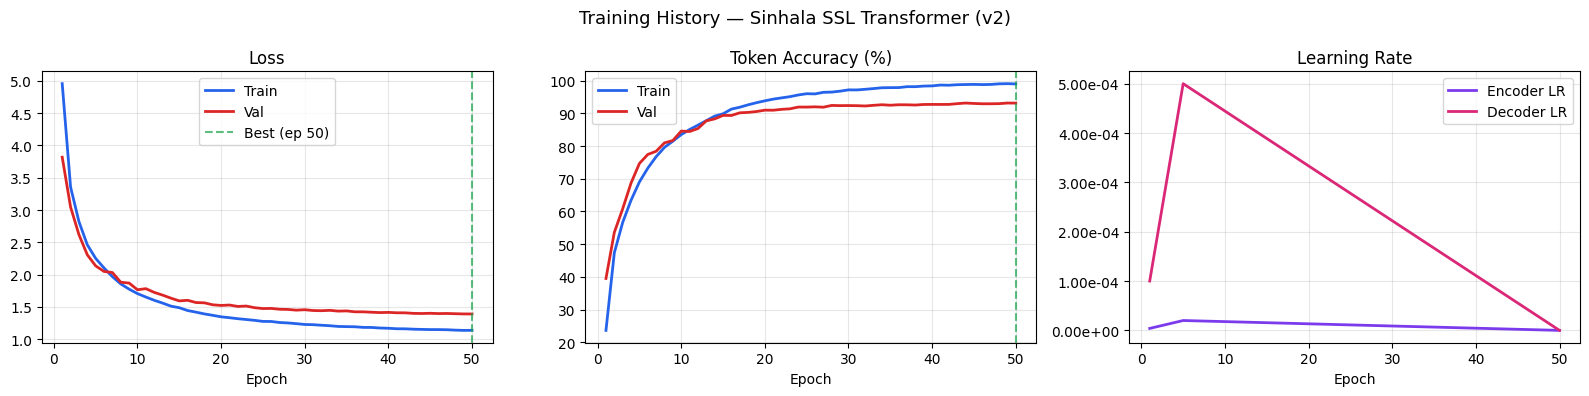


Top 5 epochs by Val Loss:
 epoch  train_loss  val_loss  train_acc  val_acc
    50    1.136024  1.389489   0.989796 0.931183
    49    1.134924  1.389993   0.990584 0.931388
    48    1.138844  1.393227   0.990082 0.929519
    46    1.147153  1.395248   0.987794 0.929133
    44    1.150288  1.396448   0.987950 0.931375


In [10]:
# ───────────────────────────────────────────────────────
# CELL 10 — Training Curves & Epoch Analysis
# ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training History — Sinhala SSL Transformer (v2)", fontsize=13)
epochs = history["epoch"]

axes[0].plot(epochs, history["train_loss"], label="Train", color="#2563eb", lw=2)
axes[0].plot(epochs, history["val_loss"],   label="Val",   color="#dc2626", lw=2)
axes[0].axvline(best_epoch, color="#16a34a", linestyle="--", alpha=0.7,
                label=f"Best (ep {best_epoch})")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history["train_acc"]],
             label="Train", color="#2563eb", lw=2)
axes[1].plot(epochs, [a*100 for a in history["val_acc"]],
             label="Val",   color="#dc2626", lw=2)
axes[1].axvline(best_epoch, color="#16a34a", linestyle="--", alpha=0.7)
axes[1].set_title("Token Accuracy (%)"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history["lr_enc"], label="Encoder LR", color="#7c3aed", lw=2)
axes[2].plot(epochs, history["lr_dec"], label="Decoder LR", color="#db2777", lw=2)
axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2e"))

plt.tight_layout()
plt.savefig(f"{CFG.OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

df_h = pd.DataFrame(history)
print("\nTop 5 epochs by Val Loss:")
print(df_h.nsmallest(5, "val_loss")
         [["epoch","train_loss","val_loss","train_acc","val_acc"]]
         .to_string(index=False))


In [ ]:
# ───────────────────────────────────────────────────────
# CELL 11 — Inference Engine
#
# Key improvements vs v1:
#   1. Beam search with length penalty (Wu et al. 2016)
#   2. Uses tgt_tokenizer (custom sign vocab) for decode
#   3. Uses parser.fuzzy_lookup() with O(1) prefix index
# ───────────────────────────────────────────────────────

def length_penalty(length: int, alpha: float = CFG.BEAM_LENGTH_PENALTY) -> float:
    """
    Length penalty from Wu et al. 2016 (Google NMT).
    lp = ((5 + |Y|) / 6) ^ alpha
    Prevents beam search from preferring short sequences.
    """
    return ((5 + max(length, 1)) / 6) ** alpha


class SSLTranslator:
    """
    Inference pipeline:
      1. Encode Sinhala text with XLM-RoBERTa
      2. Beam search decode → sign token IDs  (custom sign vocab)
      3. Decode token IDs → gloss words  (tgt_tokenizer)
      4. Map gloss words → SSL sign IDs  (parser.word2id / fuzzy_lookup)
    """

    def __init__(self, model, src_tok, tgt_tok,
                 parser, device, cfg=CFG):
        self.model   = model
        self.src_tok = src_tok
        self.tgt_tok = tgt_tok
        self.parser  = parser   # has word2id + fuzzy_lookup
        self.device  = device
        self.cfg     = cfg

    @torch.no_grad()
    def _greedy(self, memory: torch.Tensor,
                attn_mask: torch.Tensor,
                max_len: int = CFG.MAX_TGT_LEN) -> List[int]:
        generated = [TGT_BOS_ID]
        for _ in range(max_len):
            tgt     = torch.tensor([generated], device=self.device)
            dec_out = self.model.decode_step(tgt, memory, attn_mask)
            nxt     = self.model.output_proj(
                dec_out[:, -1, :]).argmax(-1).item()
            if nxt == TGT_EOS_ID:
                break
            generated.append(nxt)
        return generated[1:]   # strip BOS

    @torch.no_grad()
    def _beam(self, memory: torch.Tensor,
              attn_mask: torch.Tensor,
              beam_size: int = CFG.BEAM_SIZE,
              max_len: int   = CFG.MAX_TGT_LEN) -> List[int]:
        """
        Beam search with Wu et al. 2016 length penalty.

        Each beam candidate: (token_ids_list, cumulative_log_prob)
        Final score = cumulative_log_prob / length_penalty(len)
        """
        beams = [([TGT_BOS_ID], 0.0)]
        done  = []

        for _ in range(max_len):
            if not beams:
                break
            all_cands = []
            for seq, score in beams:
                tgt     = torch.tensor([seq], device=self.device)
                dec_out = self.model.decode_step(tgt, memory, attn_mask)
                lp      = F.log_softmax(
                    self.model.output_proj(
                        dec_out[:, -1, :]
                    ).squeeze(0), dim=-1)
                top_v, top_i = lp.topk(beam_size)
                for v, i in zip(top_v.tolist(), top_i.tolist()):
                    all_cands.append((seq + [i], score + v))

            # Sort by raw score (length penalty applied at the end)
            all_cands.sort(key=lambda x: x[1], reverse=True)

            beams = []
            for seq, sc in all_cands[:beam_size * 2]:
                if seq[-1] == TGT_EOS_ID:
                    hyp_ids = seq[1:-1]   # strip BOS + EOS
                    normed  = sc / length_penalty(len(hyp_ids))
                    done.append((hyp_ids, normed))
                else:
                    beams.append((seq, sc))
                if len(beams) >= beam_size:
                    break

        # If nothing finished, take the best active beam
        if not done:
            if beams:
                best_seq, best_sc = max(beams, key=lambda x: x[1])
                hyp_ids = best_seq[1:]
                done.append((hyp_ids,
                              best_sc / length_penalty(len(hyp_ids))))
            else:
                return []

        done.sort(key=lambda x: x[1], reverse=True)
        return done[0][0]

    def translate(self, text: str,
                  beam_size: int = CFG.BEAM_SIZE) -> Dict:
        self.model.eval()
        enc = self.src_tok(
            text,
            max_length=self.cfg.MAX_SRC_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        ).to(self.device)
        memory = self.model.encode(enc["input_ids"], enc["attention_mask"])

        token_ids = (
            self._beam(memory, enc["attention_mask"], beam_size)
            if beam_size > 1
            else self._greedy(memory, enc["attention_mask"])
        )

        # Decode token IDs → gloss words
        gloss_text  = self.tgt_tok.decode(token_ids, skip_special=True)
        gloss_words = [w for w in gloss_text.split() if w.strip()]

        # Map gloss words → SSL sign IDs
        ssl_tokens = []
        for word in gloss_words:
            sid = self.parser.word2id.get(word)
            if sid is None:
                # Use O(1) prefix index fuzzy lookup
                word, sid = self.parser.fuzzy_lookup(word)
            ssl_tokens.append({"word": word, "sign_id": sid})

        return {
            "source"     : text,
            "gloss_text" : gloss_text,
            "gloss_words": gloss_words,
            "ssl_tokens" : ssl_tokens,
            "ssl_string" : " | ".join(
                f"{t['sign_id']}:{t['word']}"
                for t in ssl_tokens
                if t["sign_id"] is not None),
        }


# Load best checkpoint
ckpt = torch.load(f"{CFG.MODEL_DIR}/best_model.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"✓ Best model loaded  "
      f"(epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")

translator = SSLTranslator(
    model, src_tokenizer, tgt_tokenizer, parser, DEVICE, CFG)
print("✓ Translator ready")


✓ Best model loaded  (epoch 50, val_loss=1.3895)
✓ Translator ready


In [13]:
# ───────────────────────────────────────────────────────
# CELL 12 — Test Set Evaluation  +  All NLG Metrics
#
# Metrics:
#   Task-specific : Gloss Word Acc, Sign ID Acc, Exact Match
#   N-gram        : BLEU-4, chrF, TER
#   Recall-based  : ROUGE-1, ROUGE-2, ROUGE-L
#   Other         : METEOR, WER
#   Semantic      : BERTScore (xlm-roberta-base — supports Sinhala)
#
# BERTScore note: Sinhala is in XLM-R's 100-language list.
# Standard BERTScore does not have an official Sinhala baseline
# for rescaling (NSina 2024); raw scores are reported as
# recommended by Tang et al. 2023 for low-resource languages.
# ───────────────────────────────────────────────────────
import sacrebleu
from rouge_score import rouge_scorer as rs_mod
from nltk.translate.meteor_score import meteor_score
import nltk
from jiwer import wer as jiwer_wer
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)


# ── Step 1: collect raw predictions ─────────────────────────────
def run_test_set(translator, test_pairs: List[Dict]):
    results   = []
    word_hits = id_hits = total_ref = 0

    eval_start = time.time()
    import tqdm
    for pair in tqdm.tqdm(test_pairs):
        pred = translator.translate(pair["source"],
                                    beam_size=CFG.BEAM_SIZE)

        ref_words  = set(pair["gloss_words"])
        pred_words = set(pred["gloss_words"])
        ref_ids    = set(pair["target_ids"])
        pred_ids   = set(t["sign_id"] for t in pred["ssl_tokens"]
                         if t["sign_id"] is not None)

        wh = len(ref_words & pred_words)
        ih = len(ref_ids   & pred_ids)
        word_hits += wh
        id_hits   += ih
        total_ref += len(ref_words)

        results.append({
            "source"      : pair["source"],
            "reference"   : pair["target_text"],
            "prediction"  : pred["gloss_text"],
            "ref_ids"     : pair["target_ids"],
            "pred_ids"    : list(pred_ids),
            "word_overlap": round(wh / max(len(ref_words), 1), 3),
            "id_overlap"  : round(ih / max(len(ref_ids),   1), 3),
            "exact_match" : int(pred_words == ref_words),
        })

    eval_secs = time.time() - eval_start
    print(f"Eval: {eval_secs:.2f}s  |  Avg: {eval_secs/len(test_pairs)*1000:.1f}ms/sentence")

    word_acc  = word_hits / max(total_ref, 1) * 100
    id_acc    = id_hits   / max(total_ref, 1) * 100
    exact_pct = sum(r["exact_match"] for r in results) / len(results) * 100
    return results, word_acc, id_acc, exact_pct


# ── Step 2: compute all NLG metrics ─────────────────────────────
def compute_all_metrics(results: List[Dict]) -> Dict:
    predictions = [r["prediction"] for r in results]
    references  = [r["reference"]  for r in results]
    refs_sb     = [[r] for r in references]   # sacrebleu format

    # ── BLEU-4 ───────────────────────────────────────────────────
    bleu = sacrebleu.corpus_bleu(predictions, list(zip(*refs_sb)))

    # ── chrF  (best for morphologically complex Sinhala) ─────────
    chrf = sacrebleu.corpus_chrf(predictions, list(zip(*refs_sb)))

    # ── TER ──────────────────────────────────────────────────────
    ter  = sacrebleu.corpus_ter(predictions, list(zip(*refs_sb)))

    # ── ROUGE ────────────────────────────────────────────────────
    scorer = rs_mod.RougeScorer(
        ["rouge1", "rouge2", "rougeL"], use_stemmer=False)
    r1, r2, rl = [], [], []
    for pred, ref in zip(predictions, references):
        s = scorer.score(ref, pred)
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rl.append(s["rougeL"].fmeasure)

    # ── METEOR ───────────────────────────────────────────────────
    # Note: WordNet synonym matching won't fire for Sinhala,
    # but unigram overlap portion still gives a valid score.
    meteor_scores = [
        meteor_score([ref.split()], pred.split())
        for pred, ref in zip(predictions, references)
    ]

    # ── WER ──────────────────────────────────────────────────────
    wer_score = jiwer_wer(references, predictions) * 100

    # ── BERTScore  (xlm-roberta-base, layer 9) ───────────────────
    # XLM-R explicitly lists Sinhala in its 100-language support
    # (Conneau et al. 2020). Layer 9 is optimal for xlm-roberta-base
    # per BERTScore's own model selection guidelines.
    try:
        from bert_score import score as bscore
        P, R, F1 = bscore(
            predictions, references,
            model_type="xlm-roberta-base",
            num_layers=9,
            lang=None,        # bypass language lookup, use model directly
            verbose=False,
            batch_size=32)
        bs = {
            "P" : P.mean().item(),
            "R" : R.mean().item(),
            "F1": F1.mean().item()
        }
    except Exception as e:
        print(f"  BERTScore skipped: {e}")
        bs = {"P": None, "R": None, "F1": None}

    return {
        "bleu"   : bleu.score,
        "chrf"   : chrf.score,
        "ter"    : ter.score,
        "rouge1" : sum(r1) / len(r1) * 100,
        "rouge2" : sum(r2) / len(r2) * 100,
        "rougeL" : sum(rl) / len(rl) * 100,
        "meteor" : sum(meteor_scores) / len(meteor_scores) * 100,
        "wer"    : wer_score,
        "bert_P" : bs["P"],
        "bert_R" : bs["R"],
        "bert_F1": bs["F1"],
    }


# ── Run ──────────────────────────────────────────────────────────
print("Running test set evaluation (beam search)...")
test_results, word_acc, id_acc, exact_pct = run_test_set(
    translator, test_pairs)

# print("Computing NLG metrics...")
# metrics = compute_all_metrics(test_results)

# # ── Print ─────────────────────────────────────────────────────────
# print(f"\n{'='*65}")
# print(f"  FULL EVALUATION   ({len(test_pairs)} test samples)")
# print(f"{'='*65}")
# print(f"\n  ── Task-specific metrics ──────────────────────────")
# print(f"  Gloss Word Accuracy  : {word_acc:.2f}%")
# print(f"  SSL Sign ID Accuracy : {id_acc:.2f}%")
# print(f"  Exact Match          : {exact_pct:.2f}%")
# print(f"\n  ── N-gram metrics ──────────────────────────────────")
# print(f"  BLEU-4               : {metrics['bleu']:.2f}")
# print(f"  chrF                 : {metrics['chrf']:.2f}"
#       "  ← recommended for Sinhala morphology")
# print(f"  TER                  : {metrics['ter']:.2f}"
#       "  (lower is better)")
# print(f"\n  ── Recall-oriented ─────────────────────────────────")
# print(f"  ROUGE-1 (F1)         : {metrics['rouge1']:.2f}")
# print(f"  ROUGE-2 (F1)         : {metrics['rouge2']:.2f}")
# print(f"  ROUGE-L (F1)         : {metrics['rougeL']:.2f}")
# print(f"\n  ── Other ────────────────────────────────────────────")
# print(f"  METEOR               : {metrics['meteor']:.2f}")
# print(f"  WER                  : {metrics['wer']:.2f}"
#       "  (lower is better)")
# if metrics["bert_F1"] is not None:
#     print(f"\n  ── BERTScore (xlm-roberta-base layer 9) ────────────")
#     print(f"  Precision            : {metrics['bert_P']:.4f}")
#     print(f"  Recall               : {metrics['bert_R']:.4f}")
#     print(f"  F1                   : {metrics['bert_F1']:.4f}"
#           "  [no official Sinhala baseline; raw score]")
# print(f"{'='*65}")

# Save
pd.DataFrame(test_results).to_csv(
    f"{CFG.OUTPUT_DIR}/test_results.csv", index=False, encoding="utf-8")
# with open(f"{CFG.OUTPUT_DIR}/eval_metrics.json", "w") as f:
#     json.dump({**metrics,
#                "word_acc" : word_acc,
#                "id_acc"   : id_acc,
#                "exact_match": exact_pct}, f, indent=2)
print(f"\n✓ Results saved to {CFG.OUTPUT_DIR}")

# Sample predictions
print("\n=== Sample Predictions ===")
for r in test_results[:5]:
    print(f"\n  Source    : {r['source']}")
    print(f"  Reference : {r['reference']}")
    print(f"  Predicted : {r['prediction']}")
    print(f"  Overlap   : {r['word_overlap']*100:.0f}%")


Running test set evaluation (beam search)...


100%|██████████| 1653/1653 [17:07<00:00,  1.61it/s]

Eval: 1027.95s  |  Avg: 621.9ms/sentence

✓ Results saved to /kaggle/working

=== Sample Predictions ===

  Source    : කෞෂල්‍ය හෙට වතුර බොනවා
  Reference : ක් ගයනු කිත්ත ෂ් අ ල් යංශය හෙට වතුර බොනවා
  Predicted : ක් ෂ් අ ල් යංශය හෙට වතුර බොනවා
  Overlap   : 89%

  Source    : ක්‍රිශාන්ත අද බත් උයනවා
  Reference : ක් රකාරාංශය ඉ ශ් ආ න් ත් අ අද බත් උයනවා
  Predicted : ක් රකාරාංශය ඉ ශ් ආ න් ත් අ අද බත් උයනවා
  Overlap   : 100%

  Source    : හැමවෙලේම
  Reference : හැමවෙලේම
  Predicted : හැමතැනම
  Overlap   : 0%

  Source    : මම රුපියල් 423 ක් දුන්නා
  Reference : මම රුපියල් 400 23 ක් දෙනවා ඉවරයි
  Predicted : මම රුපියල් 400 23 ක් දෙනවා ඉවරයි
  Overlap   : 100%

  Source    : අපි ගිලන් රථයට කතා කරනවා
  Reference : අපි ගිලන්‍ රථය ට කතා කරනවා
  Predicted : අපි ට
  Overlap   : 50%


NameError: name 'metrics' is not defined

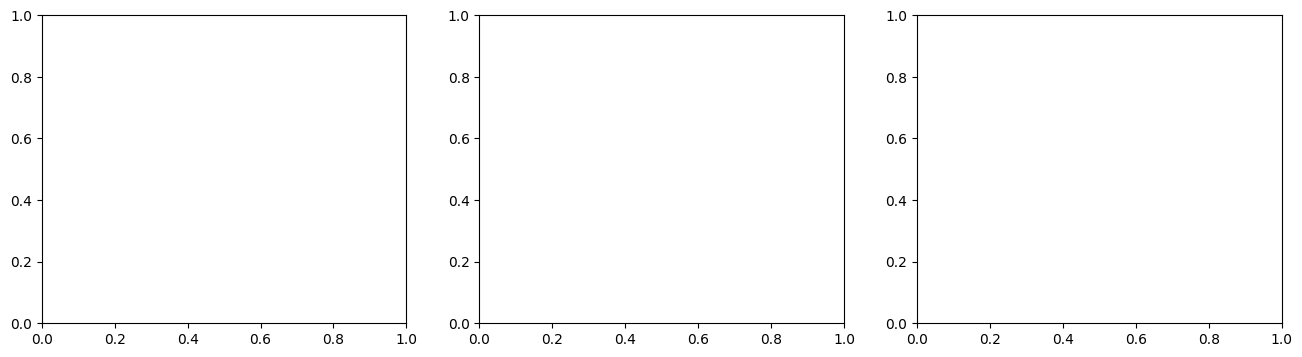

In [14]:
# ───────────────────────────────────────────────────────
# CELL 13 — Evaluation Visualization
# ───────────────────────────────────────────────────────
df_r = pd.DataFrame(test_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(
    f"Test Evaluation  |  BLEU: {metrics['bleu']:.1f}  "
    f"|  chrF: {metrics['chrf']:.1f}  "
    f"|  Exact: {exact_pct:.1f}%",
    fontsize=12)

axes[0].hist(df_r["word_overlap"]*100, bins=10,
             color="#2563eb", edgecolor="white", alpha=0.85)
axes[0].axvline(df_r["word_overlap"].mean()*100, color="#dc2626",
                linestyle="--", lw=2,
                label=f"Mean={df_r['word_overlap'].mean()*100:.1f}%")
axes[0].set_title("Gloss Word Overlap")
axes[0].set_xlabel("Overlap (%)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(df_r["id_overlap"]*100, bins=10,
             color="#7c3aed", edgecolor="white", alpha=0.85)
axes[1].axvline(df_r["id_overlap"].mean()*100, color="#dc2626",
                linestyle="--", lw=2,
                label=f"Mean={df_r['id_overlap'].mean()*100:.1f}%")
axes[1].set_title("SSL Sign ID Overlap")
axes[1].set_xlabel("Overlap (%)"); axes[1].legend(); axes[1].grid(alpha=0.3)

counts = [df_r["exact_match"].sum(),
          len(df_r) - df_r["exact_match"].sum()]
axes[2].bar(["Exact Match", "Partial/Miss"], counts,
            color=["#16a34a", "#dc2626"], edgecolor="white", alpha=0.85)
axes[2].set_title("Exact vs Partial Match")
for i, c in enumerate(counts):
    axes[2].text(i, c + 0.5, str(c), ha="center", fontsize=11)
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{CFG.OUTPUT_DIR}/evaluation_results.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Evaluation plots saved")


In [ ]:
# ───────────────────────────────────────────────────────
# CELL 14 — Translate Unseen Sentences
# ───────────────────────────────────────────────────────
UNSEEN_SENTENCES = [
    "ඔයා කොහෙද ඉන්නේ",
    "අපි හෙට ගමට යමු",
    "ඔයාගේ නම මොකක්ද",
    "මම ගෙදර යනවා",
    "ඔබට ස්තූතියි",
    # ── Add your own sentences here ──
]

print("=" * 65)
print("  SINHALA → SIGN LANGUAGE GLOSS TRANSLATION")
print("=" * 65)

for sentence in UNSEEN_SENTENCES:
    result = translator.translate(sentence, beam_size=CFG.BEAM_SIZE)
    print(f"\n📝 Source     : {result['source']}")
    print(f"🤟 Gloss Words : {result['gloss_text']}")
    print(f"🆔 SSL Output  : {result['ssl_string']}")
    print(f"   Sign tokens :")
    for tok in result["ssl_tokens"]:
        sid  = tok["sign_id"]
        word = tok["word"]
        tag  = f"Sign ID: {sid}" if sid else "⚠ not in vocab"
        print(f"      {word:20s} → {tag}")
    print("-" * 65)


def translate_sinhala(text: str, beam_size: int = CFG.BEAM_SIZE) -> Dict:
    """
    Translate a single Sinhala sentence to SSL tokens.

    Usage:
        result = translate_sinhala("ඔයා හොඳද")
        print(result["ssl_string"])

    Returns dict with keys:
        source, gloss_text, gloss_words, ssl_tokens, ssl_string
    """
    result = translator.translate(text, beam_size=beam_size)
    print(f"Source  : {result['source']}")
    print(f"Gloss   : {result['gloss_text']}")
    print(f"SSL IDs : {result['ssl_string']}")
    return result

# Try it:
# translate_sinhala("ඔයා හොඳද")
# translate_sinhala("අම්මා ගෙදර ඉන්නවාද")


In [ ]:
# ───────────────────────────────────────────────────────
# CELL 15 — Save Everything & Final Summary
# ───────────────────────────────────────────────────────
# Save tokenizers
src_tokenizer.save_pretrained(f"{CFG.MODEL_DIR}/src_tokenizer")
tgt_tokenizer.save(f"{CFG.MODEL_DIR}/sign_tokenizer.json")

summary = {
    "best_epoch"        : best_epoch,
    "best_val_loss"     : best_val_loss,
    "test_word_acc"     : word_acc,
    "test_id_acc"       : id_acc,
    "test_exact_match"  : exact_pct,
    "bleu4"             : metrics["bleu"],
    "chrf"              : metrics["chrf"],
    "ter"               : metrics["ter"],
    "rouge1"            : metrics["rouge1"],
    "rouge2"            : metrics["rouge2"],
    "rougeL"            : metrics["rougeL"],
    "meteor"            : metrics["meteor"],
    "wer"               : metrics["wer"],
    "bert_f1"           : metrics["bert_F1"],
    "train_size"        : len(train_pairs),
    "val_size"          : len(val_pairs),
    "test_size"         : len(test_pairs),
    "ssl_vocab_size"    : len(parser.word2id),
    "sign_token_vocab"  : tgt_tokenizer.vocab_size,
    "encoder"           : CFG.ENCODER_MODEL,
    "frozen_enc_layers" : CFG.FREEZE_ENCODER_LAYERS,
    "total_epochs"      : len(history["epoch"]),
}

with open(f"{CFG.OUTPUT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("  FINAL SUMMARY")
print("="*60)
for k, v in summary.items():
    print(f"  {k:25s}: {v}")
print("="*60)

print(f"\n✓ All outputs saved to: {CFG.OUTPUT_DIR}")
print(f"\nKaggle output files:")
for fp in sorted(Path(CFG.OUTPUT_DIR).rglob("*")):
    if fp.is_file():
        kb = fp.stat().st_size / 1024
        print(f"  {str(fp.relative_to(CFG.OUTPUT_DIR)):50s}  {kb:.0f} KB")
